In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
filePath = '../Dataset/UCI_Gallstone_Dataset.csv'
df = pd.read_csv(filePath)
df

,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,...,High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,...,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,...,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,...,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,...,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,...,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314,1,49,0,0,0,0,0,0,178,88.8,...,55.0,81.0,28.0,50.0,90.0,0.98,94.50,6.2,16.5,8.3
315,1,31,1,0,0,0,0,0,157,53.4,...,58.0,64.0,24.0,16.0,38.0,0.50,128.50,0.0,12.5,24.0
316,1,58,0,0,0,0,0,0,172,96.6,...,45.0,168.0,21.0,27.0,94.0,1.04,83.23,0.0,15.4,15.7
317,1,37,1,0,0,0,0,0,177,88.4,...,33.0,253.0,40.0,22.0,115.0,1.01,98.23,0.4,16.0,33.3


In [10]:
df.isnull().values.any()

np.False_

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 39 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Gallstone Status                                319 non-null    int64  
 1   Age                                             319 non-null    int64  
 2   Gender                                          319 non-null    int64  
 3   Comorbidity                                     319 non-null    int64  
 4   Coronary Artery Disease (CAD)                   319 non-null    int64  
 5   Hypothyroidism                                  319 non-null    int64  
 6   Hyperlipidemia                                  319 non-null    int64  
 7   Diabetes Mellitus (DM)                          319 non-null    int64  
 8   Height                                          319 non-null    int64  
 9   Weight                                     

In [12]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Gallstone Status,319.0,0.495298,0.500763,0.00,0.000,0.000000,1.000,1.00
Age,319.0,48.068966,12.114558,20.00,38.500,49.000000,56.000,96.00
Gender,319.0,0.492163,0.500724,0.00,0.000,0.000000,1.000,1.00
Comorbidity,319.0,0.335423,0.517340,0.00,0.000,0.000000,1.000,3.00
Coronary Artery Disease (CAD),319.0,0.037618,0.190568,0.00,0.000,0.000000,0.000,1.00
Hypothyroidism,319.0,0.028213,0.165841,0.00,0.000,0.000000,0.000,1.00
Hyperlipidemia,319.0,0.025078,0.156609,0.00,0.000,0.000000,0.000,1.00
Diabetes Mellitus (DM),319.0,0.134796,0.342042,0.00,0.000,0.000000,0.000,1.00
Height,319.0,167.156740,10.053030,145.00,159.500,168.000000,175.000,191.00
Weight,319.0,80.564890,15.709069,42.90,69.600,78.800000,91.250,143.50


In [13]:
# [GROUP 1] Demographic & Anthropometric Baselines
# Method: Electronic Health Records (EHR) & Standard Physical Measurement.
# - Demographics: Age (Years) and Gender (Binary: 0=Male, 1=Female).
# - Anthropometry: Height (cm), Weight (kg), and Body Mass Index (kg/m²).
df_demographic = df[[
    'Age',
    'Gender',
    'Height',
    'Weight',
    'Body Mass Index (BMI)'
]].copy()

# [GROUP 2] Clinical History
# Method: Medical History Review (Binary Classification).
# - Comorbidities: Presence of any comorbidity condition (1=Yes, 0=No).
# - Specific Conditions: Diagnosed history of CAD, Hypothyroidism, etc.
df_comorbidities = df[[
    'Comorbidity',
    'Coronary Artery Disease (CAD)',
    'Hypothyroidism',
    'Hyperlipidemia',
    'Diabetes Mellitus (DM)'
]].copy()

# [GROUP 3] Bioelectrical Impedance Analysis (BIA) & Imaging
# Method A (Composition): "Tanita MC780" Body Composition Analyzer[cite: 74].
# - Protocol: Non-invasive electrical resistance measurement of tissues.
# - Metrics: TBW (kg), Fat (%), Muscle (kg), Bone (kg).
#
# Method B (Liver Fat): "Ultrasonography"[cite: 77].
# - Hepatic Fat Accumulation (HFA): Diagnosed via imaging, not BIA.
df_bioimpedance = df[[
    'Total Body Water (TBW)',
    'Extracellular Water (ECW)',
    'Intracellular Water (ICW)',
    'Extracellular Fluid/Total Body Water (ECF/TBW)',
    'Total Body Fat Ratio (TBFR) (%)',
    'Lean Mass (LM) (%)',
    'Body Protein Content (Protein) (%)',
    'Visceral Fat Rating (VFR)',
    'Bone Mass (BM)',
    'Muscle Mass (MM)',
    'Obesity (%)',
    'Total Fat Content (TFC)',
    'Visceral Fat Area (VFA)',
    'Visceral Muscle Area (VMA) (Kg)',
    'Hepatic Fat Accumulation (HFA)' # Note: Via Ultrasound, grouped here for "Body Comp" context.
]].copy()

# [GROUP 4] Laboratory & Metabolic Markers
# Method: Clinical "Blood Tests" routinely gauged in laboratories.
# Lipid/Glucose: Measured in mg/dL (Glucose, Cholesterol, LDL, HDL, Triglycerides).
# Liver Enzymes: Measured in U/L (AST, ALT, ALP).
# Renal Function: Creatinine (mg/dL) and GFR (ml/seconds).
# Specialized: CRP (mg/L), Hemoglobin (g/dL), and vitamin D (ng/mL).
df_laboratory = df[[
    'Glucose',
    'Total Cholesterol (TC)',
    'Low Density Lipoprotein (LDL)',
    'High Density Lipoprotein (HDL)',
    'Triglyceride',
    'Aspartat Aminotransferaz (AST)',
    'Alanin Aminotransferaz (ALT)',
    'Alkaline Phosphatase (ALP)',
    'Creatinine',
    'Glomerular Filtration Rate (GFR)',
    'C-Reactive Protein (CRP)',
    'Hemoglobin (HGB)',
    'Vitamin D'
]].copy()

In [14]:
data_groups = {
    "Demographic": df_demographic,
    "Clinical History": df_comorbidities,
    "Bioimpedance & Imaging": df_bioimpedance,
    "Laboratory": df_laboratory
}
print(f"{'GROUP NAME':<25} | {'SHAPE (Rows, Cols)'}\n")
for name, data in data_groups.items():
    print(f"{name:<25} | {data.shape}")

GROUP NAME                | SHAPE (Rows, Cols)

Demographic               | (319, 5)
Clinical History          | (319, 5)
Bioimpedance & Imaging    | (319, 15)
Laboratory                | (319, 13)


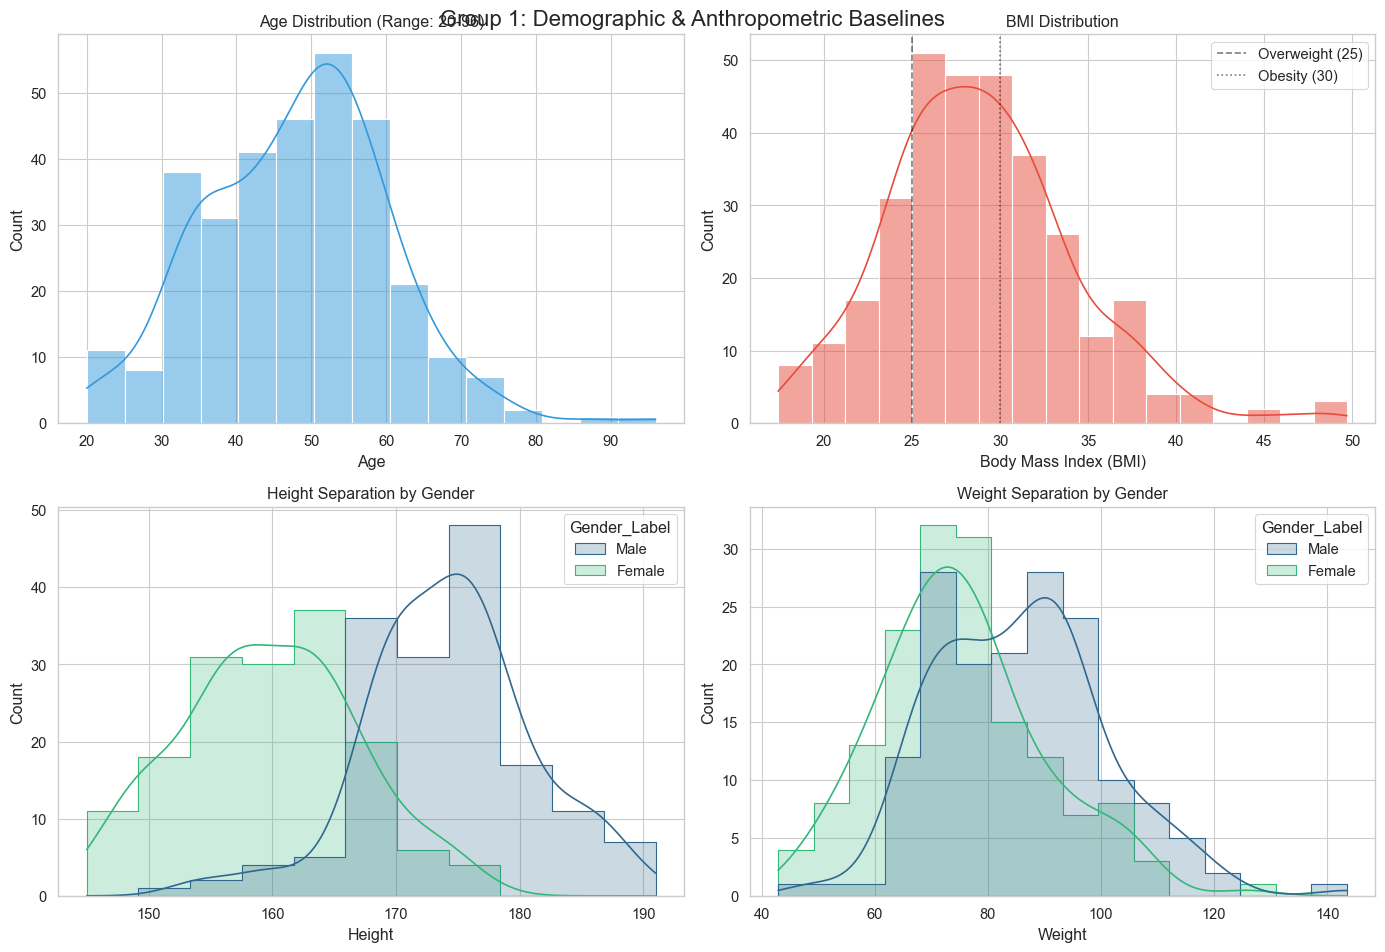

C:\Users\yqn1e23\AppData\Local\Temp\ipykernel_17752\1073579564.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='Gender_Label', y='Body Mass Index (BMI)',


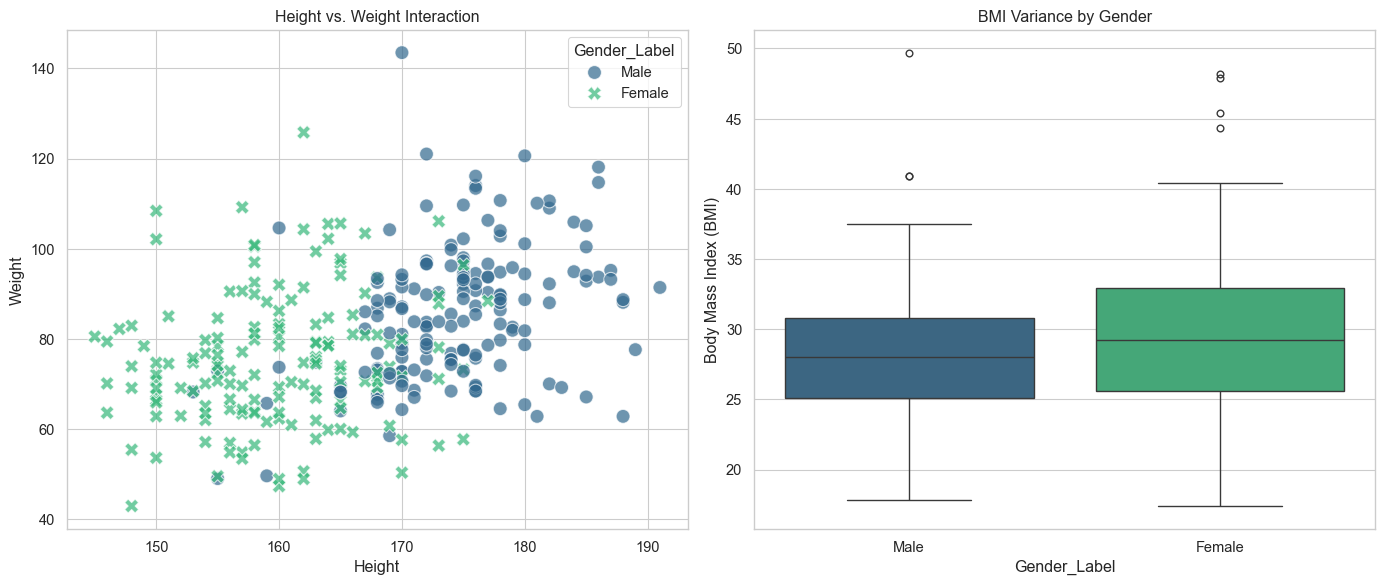

In [15]:
# --- Configuration for Academic Publishing Standards ---
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

# Create a copy for visualization to avoid SettingWithCopy warnings
plot_df = df_demographic.copy()
# Map binary gender to labels for readability
plot_df['Gender_Label'] = plot_df['Gender'].map({0: 'Male', 1: 'Female'})

# --- 1. Distribution Grid (Univariate) ---
fig1, axes = plt.subplots(2, 2, figsize=(14, 10))
fig1.suptitle('Group 1: Demographic & Anthropometric Baselines', fontsize=16, y=0.95)

# Age Distribution
sns.histplot(data=plot_df, x='Age', kde=True, ax=axes[0, 0], color='#3498db')
axes[0, 0].set_title('Age Distribution (Range: 20-96)')

# BMI Distribution with Clinical Thresholds
sns.histplot(data=plot_df, x='Body Mass Index (BMI)', kde=True, ax=axes[0, 1], color='#e74c3c')
axes[0, 1].axvline(25, color='black', linestyle='--', alpha=0.5, label='Overweight (25)')
axes[0, 1].axvline(30, color='black', linestyle=':', alpha=0.5, label='Obesity (30)')
axes[0, 1].set_title('BMI Distribution')
axes[0, 1].legend()

# Height Stratification
sns.histplot(data=plot_df, x='Height', kde=True, hue='Gender_Label',
             element="step", ax=axes[1, 0], palette="viridis")
axes[1, 0].set_title('Height Separation by Gender')

# Weight Stratification
sns.histplot(data=plot_df, x='Weight', kde=True, hue='Gender_Label',
             element="step", ax=axes[1, 1], palette="viridis")
axes[1, 1].set_title('Weight Separation by Gender')

plt.tight_layout()
plt.show()

# --- 2. Correlation Analysis (Bivariate) ---
fig2 = plt.figure(figsize=(14, 6))
gs = fig2.add_gridspec(1, 2)

# Height vs Weight
ax1 = fig2.add_subplot(gs[0, 0])
sns.scatterplot(data=plot_df, x='Height', y='Weight', hue='Gender_Label',
                style='Gender_Label', alpha=0.7, s=100, ax=ax1, palette="viridis")
ax1.set_title('Height vs. Weight Interaction')

# BMI Comparison
ax2 = fig2.add_subplot(gs[0, 1])
sns.boxplot(data=plot_df, x='Gender_Label', y='Body Mass Index (BMI)',
            palette="viridis", ax=ax2)
ax2.set_title('BMI Variance by Gender')

plt.tight_layout()
plt.show()